# Comparaison de modèles de prévision de la demande pour la supply chain (classification)

## Introduction

Après avoir tenté de prédire les volumes de ventes avec la régression, nous voulions tenter la classification. Elle pourrait être plus pertinente et plus adapté à une décision métier pour coller à notre persona de Sophie Martin. Nous pourrions ainsi identifier les périodes à risque de rupture.

---

## Préparation des données (identique à la régression)

In [16]:
import pandas as pd
import numpy as np

# Chargement des données
sales = pd.read_csv("/Users/lisaroubertie/Desktop/Cours/Inge2/S2/ProjetApplication/OptimisationPredictive_ChaineLogistique/datas/sales_train_evaluation.csv")
calendar = pd.read_csv("/Users/lisaroubertie/Desktop/Cours/Inge2/S2/ProjetApplication/OptimisationPredictive_ChaineLogistique/datas/calendar.csv")

# Transformation des colonnes en lignes
sales = sales.melt(
    id_vars=["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"],
    var_name="d", value_name="sales")

# Merge avec le calendrier pour avoir les dates et les évènements
df = sales.merge(calendar, on="d", how="left")
df["date"] = pd.to_datetime(df["date"])

# On somme toutes les ventes par jour et on récupère les variables externes
daily = df.groupby("date").agg(
    sales=("sales", "sum"),
    has_event=("event_name_1", lambda x: int(x.notna().any())),
    snap_CA=("snap_CA", "max"),
    snap_TX=("snap_TX", "max"),
    snap_WI=("snap_WI", "max")).reset_index()

# Features temporelles (identique au notebook régression)
daily["dayofweek"] = daily["date"].dt.dayofweek
daily["month"] = daily["date"].dt.month
daily["week"] = daily["date"].dt.isocalendar().week.astype(int)
daily["sin_dow"] = np.sin(2 * np.pi * daily["dayofweek"] / 7)
daily["cos_dow"] = np.cos(2 * np.pi * daily["dayofweek"] / 7)
daily["lag_1"] = daily["sales"].shift(1) 
daily["lag_7"] = daily["sales"].shift(7)
daily["lag_28"] = daily["sales"].shift(28) 
daily["rolling_mean_7"] = daily["sales"].shift(1).rolling(7).mean()
daily["rolling_std_7"]  = daily["sales"].shift(1).rolling(7).std()

daily = daily.dropna()
print(daily.shape)

(1913, 16)


### Création des classes

In [17]:
# Création des 3 classes basées sur les quantiles
# On utilise les quantiles plutôt que des seuils fixes pour que les classes soient équilibrées
q33 = daily["sales"].quantile(0.33)
q67 = daily["sales"].quantile(0.67)

print(f"Seuil faible/moyen : {q33:.0f} ventes/jour")
print(f"Seuil moyen/fort   : {q67:.0f} ventes/jour")

daily["classe"] = pd.cut(
    daily["sales"],
    bins=[-1, q33, q67, daily["sales"].max()],
    labels=["faible", "moyen", "fort"])

print(daily["classe"].value_counts())

Seuil faible/moyen : 31368 ventes/jour
Seuil moyen/fort   : 37117 ventes/jour
classe
moyen     651
faible    631
fort      631
Name: count, dtype: int64


### Visualisation de la distribution des classes

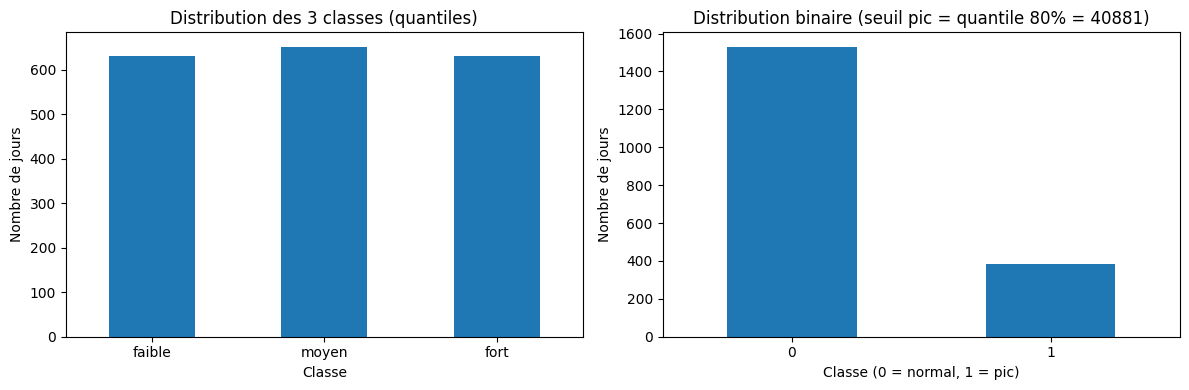

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

daily["classe"].value_counts().reindex(["faible", "moyen", "fort"]).plot(kind="bar", ax=axes[0])
axes[0].set_title("Distribution des 3 classes (quantiles)")
axes[0].set_xlabel("Classe")
axes[0].set_ylabel("Nombre de jours")
axes[0].tick_params(axis="x", rotation=0)

# Distribution binaire avec seuil quantile 80%
seuil_pic = daily["sales"].quantile(0.80)
daily["pic"] = (daily["sales"] >= seuil_pic).astype(int)
daily["pic"].value_counts().plot(kind="bar", ax=axes[1],)
axes[1].set_title(f"Distribution binaire (seuil pic = quantile 80% = {seuil_pic:.0f})")
axes[1].set_xlabel("Classe (0 = normal, 1 = pic)")
axes[1].set_ylabel("Nombre de jours")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

### Train Test Split

In [22]:
features = [
    "dayofweek", "month", "week",
    "sin_dow", "cos_dow",
    "has_event",
    "snap_CA", "snap_TX", "snap_WI",
    "lag_1", "lag_7", "lag_28",
    "rolling_mean_7", "rolling_std_7"
]

split = int(len(daily) * 0.8)
train = daily.iloc[:split]
test  = daily.iloc[split:]

X_train = train[features]
X_test = test[features]

print("Train :", train.shape, "| Test :", test.shape)

Train : (1530, 19) | Test : (383, 19)


---

## Classification 3 classes (Random Forest)

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
daily["classe_enc"] = le.fit_transform(daily["classe"])

split = int(len(daily) * 0.8)
train = daily.iloc[:split]
test  = daily.iloc[split:]

y_train_3 = train["classe_enc"]
y_test_3 = test["classe_enc"]

clf_3 = RandomForestClassifier(n_estimators=100, random_state=42)
clf_3.fit(X_train, y_train_3)
pred_3 = clf_3.predict(X_test)

print("Accuracy :", round(accuracy_score(y_test_3, pred_3), 4))
print(classification_report(y_test_3, pred_3, target_names=le.classes_))

Accuracy : 0.7624
              precision    recall  f1-score   support

      faible       0.67      0.47      0.55        17
        fort       0.98      0.68      0.80       231
       moyen       0.60      0.94      0.74       135

    accuracy                           0.76       383
   macro avg       0.75      0.70      0.70       383
weighted avg       0.83      0.76      0.77       383



Le Random Forest prédit correctement environ 3 cas sur 4, ce qui est plutot bon.

Cependant, les performances sont différentes selon les classes. La classe forte demande est la plus représenté dans les données de test (231 jours) et obtient de bons résultats avec un recall de 0.68. La classe moyenne est correctement détectée avec un recall de 0.94 mais elle est parfois confondue avec les classes voisines. Enfin, la classe faible demande contient très peu d'exemples (17 jours ce qui rend sont évaluation moins stables. Le modèle différencie globalement bien les niveaux de demandes mais certaines confusions persistent entre les classes proches. 

### Matrice de confusion pour le Random Forest

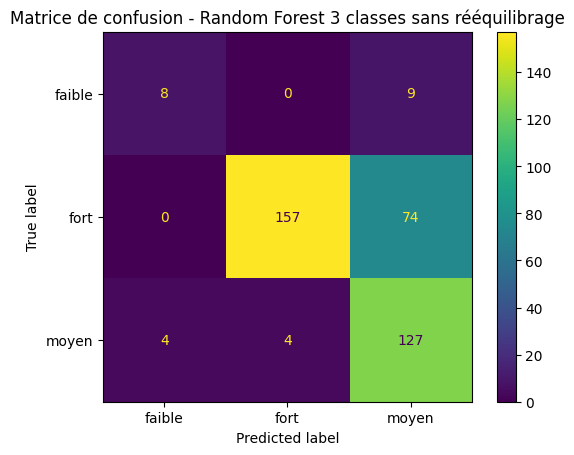

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test_3, pred_3, display_labels=le.classes_)

plt.title("Matrice de confusion - Random Forest 3 classes sans rééquilibrage")
plt.show()

La matrice de confusion confirme que la classe 'fort' est très bien identifiée mais que le modèle confond fréquemment 'moyen' et 'fort'. 

Par ailleurs, on constate aussi que le modèle à tendance à confondre la classe vraie avec la classe la plus proche (ex : 'faible' avec 'moyen', 'fort' avec 'moyen' et 'moyen' avec 'faible'), ce qui est plutot positif car cela montre qu'il différencie relativement bien les niveaux extrêmes et confond principalement les classes voisines.

---

## Classification 3 classes avec balance

Pour ce modèle, nous ajoutons une balance pour équilibrer les classes et tenter d'obtenir des meilleurs résultats en classe 2.

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

clf_3_equilibre = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
clf_3_equilibre.fit(X_train_3, y_train_3)
pred_3_equilibre = clf_3_equilibre.predict(X_test_3)

print("Accuracy :", round(accuracy_score(y_test_3, pred_3_equilibre), 4))
print(classification_report(y_test_3, pred_3_equilibre, target_names=le.classes_))

Accuracy : 0.765
              precision    recall  f1-score   support

      faible       0.60      0.53      0.56        17
        fort       0.99      0.68      0.81       231
       moyen       0.61      0.94      0.74       135

    accuracy                           0.77       383
   macro avg       0.73      0.72      0.70       383
weighted avg       0.84      0.77      0.77       383



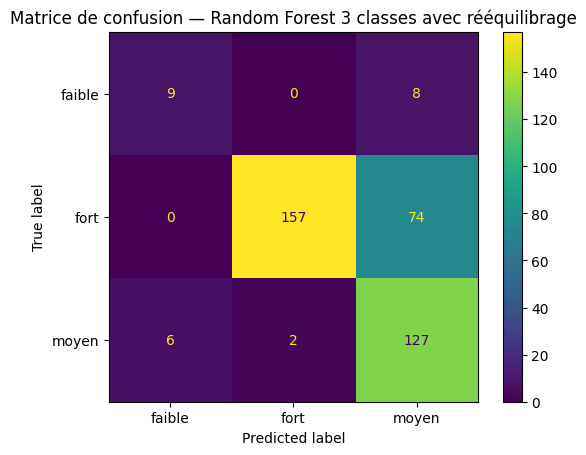

In [10]:
# Matrice de confusion — 3 classes avec rééquilibrage

ConfusionMatrixDisplay.from_predictions(
    y_test_3, pred_3_equilibre,
    display_labels=le.classes_)
plt.title("Matrice de confusion — Random Forest 3 classes avec rééquilibrage")
plt.show()

Le modèle avec rééquilibrage conserve des performances globales proches du modèle précédent tout en améliorant légèrement l’équilibre entre les classes.

---

## Transformation en modèle binaire

Nous allons maintenant voir s'il serait intéressant de transformer notre problème en problème binaire. 0 serait normal et 1 représenterait un pic. Nous pourrions donc prédire les situations à risque.

Accuracy : 0.8799
              precision    recall  f1-score   support

      Normal       0.85      0.98      0.91       246
         Pic       0.95      0.70      0.81       137

    accuracy                           0.88       383
   macro avg       0.90      0.84      0.86       383
weighted avg       0.89      0.88      0.87       383



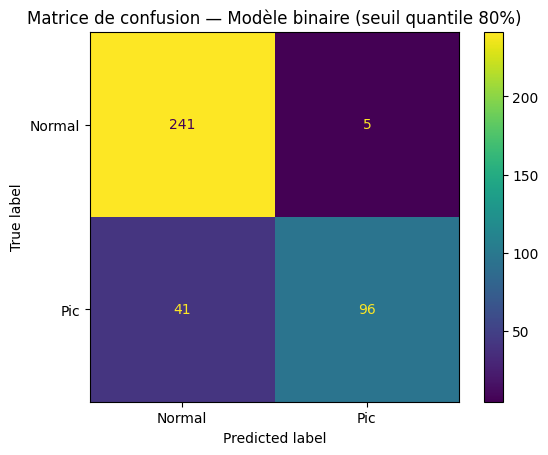

In [26]:
y_train_binaire = train["pic"]
y_test_binaire = test["pic"]

clf_binaire = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
clf_binaire.fit(X_train, y_train_binaire)
pred_binaire = clf_bin.predict(X_test)

print("Accuracy :", round(accuracy_score(y_test_binaire, pred_binaire), 4))
print(classification_report(y_test_binaire, pred_binaire, target_names=["Normal", "Pic"]))

# Matrice de confusion — modèle binaire
ConfusionMatrixDisplay.from_predictions(y_test_binaire, pred_binaire, display_labels=["Normal", "Pic"])

plt.title("Matrice de confusion — Modèle binaire (seuil quantile 80%)")
plt.show()

Ici, l'accuracy est très bonne mais un peu trompeuse. Il y a tellement de données de classe 0 que le modèle considère qu'il a bien appris parce qu'il réussit dans 98% des cas à prédire la classe 0, mais lorsqu'on regarde la classe 1, on se rend compte qu'il tombe à 70% de bonne prédiction de pics. Cela est plutot positif et est notre meilleur modèle du notebook.

---

## Conclusion

Nous avons comparé plusieurs approches de classification afin de prédire les niveaux de demande et identifier les périodes à risque pour la supply chain.

Le modèle Random Forest à 3 classes obtient une accuracy d’environ 76%, avec de bonnes performances sur les classes majoritaires. Il parvient globalement à distinguer les différents niveaux de demande, même si certaines confusions restent entre les classes proches.

L’ajout d’un rééquilibrage des classes n’apporte pas vraiment d'amélioration. Les performances sont similaires au modèle initial.

Le modèle binaire, visant uniquement à détecter les pics de demande, obtient les meilleurs résultats globaux avec une accuracy proche de 88% et un recall de 70% sur la classe des pics.

In [27]:
from sklearn.metrics import recall_score, f1_score

resultats_classif = pd.DataFrame({
    "Modèle": [
        "3 classes sans rééquilibrage",
        "3 classes avec rééquilibrage",
        "Binaire avec quantile à 80%"
    ],
    "Accuracy": [
        round(accuracy_score(y_test_3, pred_3),  4),
        round(accuracy_score(y_test_3, pred_3_equilibre), 4),
        round(accuracy_score(y_test_binaire, pred_binaire),4)
    ],
    "Recall classe forte / pic": [
        round(recall_score(y_test_3, pred_3,  average=None)[le.transform(["fort"])[0]], 4),
        round(recall_score(y_test_3, pred_3_equilibre, average=None)[le.transform(["fort"])[0]], 4),
        round(recall_score(y_test_binaire, pred_binaire, pos_label=1), 4)
    ],
    "F1 macro": [
        round(f1_score(y_test_3, pred_3,  average="macro"), 4),
        round(f1_score(y_test_3, pred_3_equilibre, average="macro"), 4),
        round(f1_score(y_test_binaire, pred_binaire, average="macro"), 4)
    ]
})

print(resultats_classif.to_string(index=False))

                      Modèle  Accuracy  Recall classe forte / pic  F1 macro
3 classes sans rééquilibrage    0.7624                     0.6797    0.6963
3 classes avec rééquilibrage    0.7650                     0.6797    0.7020
 Binaire avec quantile à 80%    0.8799                     0.7007    0.8598


---

## Export du modèle binaire pour Streamlit

In [31]:
import joblib

clf_binaire_final = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
clf_binaire_final.fit(daily[features], daily["pic"])

joblib.dump(clf_binaire_final, "model_classification_global.pkl")
joblib.dump(seuil_pic, "seuil_pic_global.pkl")

print("Modèle de classification sauvegardé.")

Modèle de classification sauvegardé.
